## **0. Setup & Import Libraries**

In [2]:
# Sel 1: Import Library & Setup Path
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import string

# Mengabaikan peringatan agar output notebook tetap bersih
import warnings
warnings.filterwarnings('ignore')

# Supaya plot matplotlib tampil proporsional di dalam notebook
%matplotlib inline

## **1. Load All Metadata Files**

In [3]:
# Path relatif dari folder 'notebook' ke folder 'data'
BASE_DATA_DIR = '../data'

# Daftar keempat dataset sesuai struktur folder Anda
datasets = [
    'sibi_alphabet_mono_bg_no_augmentation',
    'sibi_alphabet_mono_bg_with_augmentation',
    'sibi_alphabet_multi_bg_no_augmentation',
    'sibi_alphabet_multi_bg_with_augmentation'
]

splits = ['train', 'val', 'test']

print("Library siap. Path utama diatur ke:", BASE_DATA_DIR)

print(f"Direktori Proyek Utama: {BASE_DATA_DIR}")
print(f"Direktori Dataset: {BASE_DATA_DIR}")
print("Setup path berhasil!")

Library siap. Path utama diatur ke: ../data
Direktori Proyek Utama: ../data
Direktori Dataset: ../data
Setup path berhasil!


## **2. Visualisasi Komparatif 4 Variasi Dataset**

Menarik sampel acak dan membandingkan secara visual apa perbedaan nyata dari mono_bg, multi_bg, no_aug, dan with_aug.

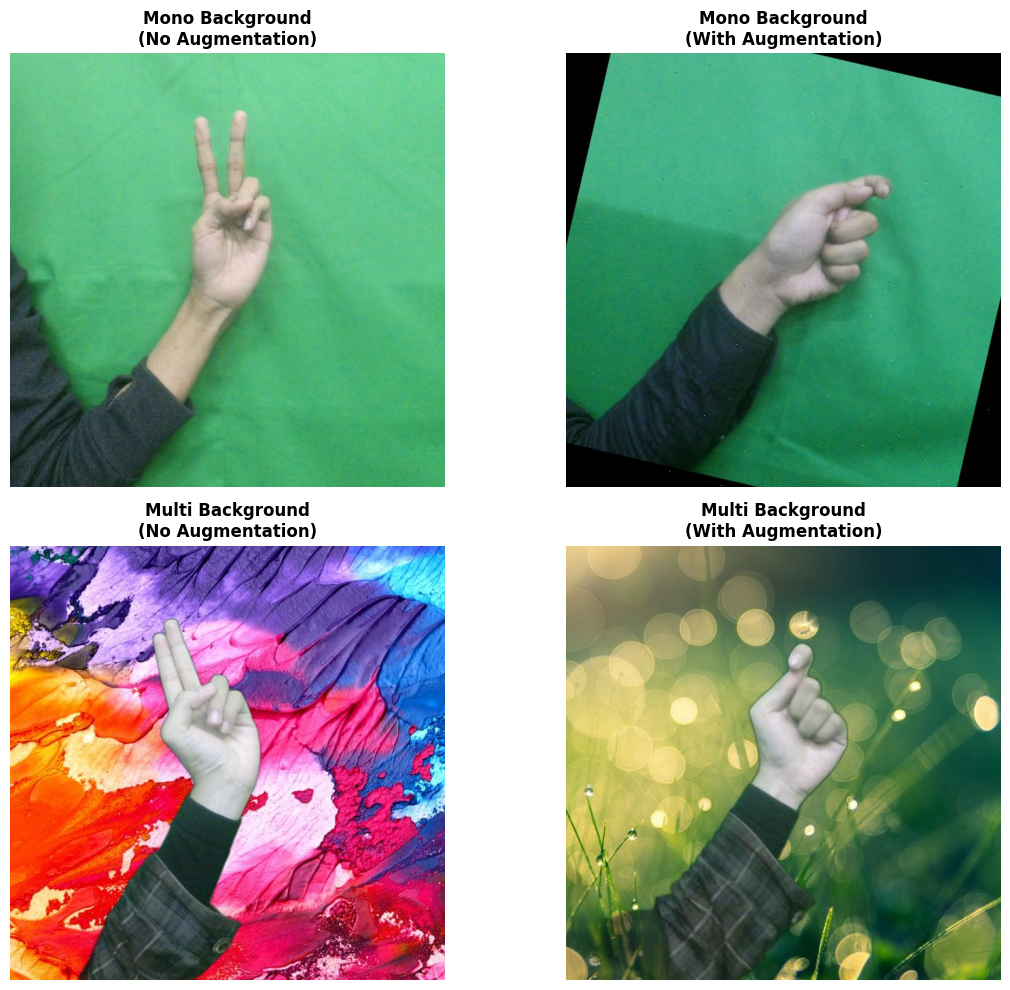

In [18]:
# %%
import random

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Judul untuk masing-masing subplot
titles = [
    'Mono Background\n(No Augmentation)', 
    'Mono Background\n(With Augmentation)',
    'Multi Background\n(No Augmentation)', 
    'Multi Background\n(With Augmentation)'
]

for i, ds in enumerate(datasets):
    # Cari gambar acak di folder train masing-masing dataset
    img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', 'train')
    
    # PERBAIKAN: Pencarian rekursif untuk mencari gambar acak
    all_imgs = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
    all_imgs = [f for f in all_imgs if os.path.isfile(f)]
    
    if all_imgs:
        random_img_path = random.choice(all_imgs)
        
        # Baca gambar dan konversi BGR ke RGB
        img = cv2.imread(random_img_path)
        if img is not None:
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            axes[i].imshow(img_rgb)
        else:
            axes[i].text(0.5, 0.5, 'Gagal memuat gambar', ha='center')
            
        axes[i].set_title(titles[i], fontsize=12, fontweight='bold')
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, 'Gambar tidak ditemukan', ha='center')
        axes[i].set_title(titles[i])
        axes[i].axis('off')

plt.tight_layout()
plt.show()

## **2. Rekapitulasi Jumlah Data Keseluruhan**

Menghitung seluruh baris data (gambar dan label teksnya) di setiap folder train, val, dan test untuk keempat variasi dataset guna memastikan tidak ada data yang corrupt atau hilang.

,Dataset,Total Gambar,Total Label,Status
0,mono_bg_no_augmentation,1440,1440,Aman
1,mono_bg_with_augmentation,3870,3870,Aman
2,multi_bg_no_augmentation,7200,7200,Aman
3,multi_bg_with_augmentation,19439,19440,Selisih!


,Tipe Dataset,Split,Jml Gambar,Jml Label,Status
0,mono_bg_no_augmentation,TRAIN,1215,1215,Aman
1,mono_bg_no_augmentation,VAL,150,150,Aman
2,mono_bg_no_augmentation,TEST,75,75,Aman
3,mono_bg_with_augmentation,TRAIN,3645,3645,Aman
4,mono_bg_with_augmentation,VAL,150,150,Aman
5,mono_bg_with_augmentation,TEST,75,75,Aman
6,multi_bg_no_augmentation,TRAIN,6120,6120,Aman
7,multi_bg_no_augmentation,VAL,720,720,Aman
8,multi_bg_no_augmentation,TEST,360,360,Aman
9,multi_bg_with_augmentation,TRAIN,18359,18360,Selisih!


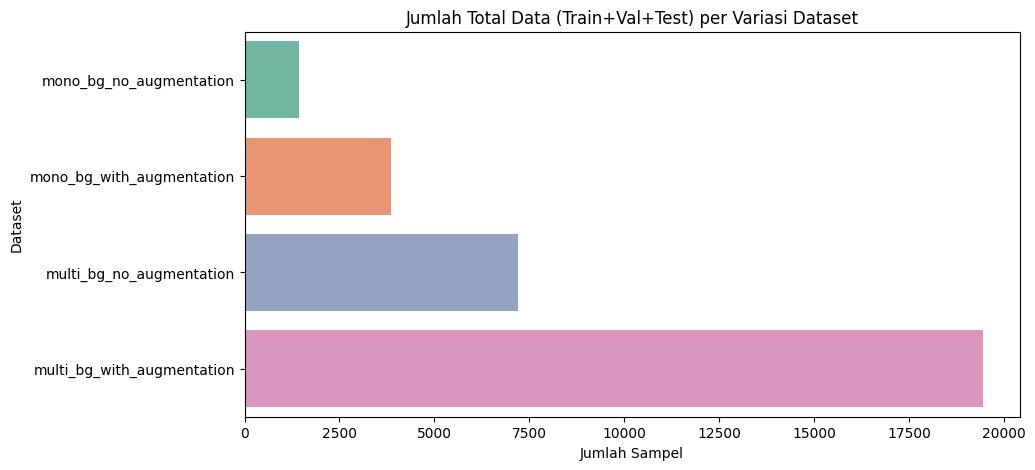

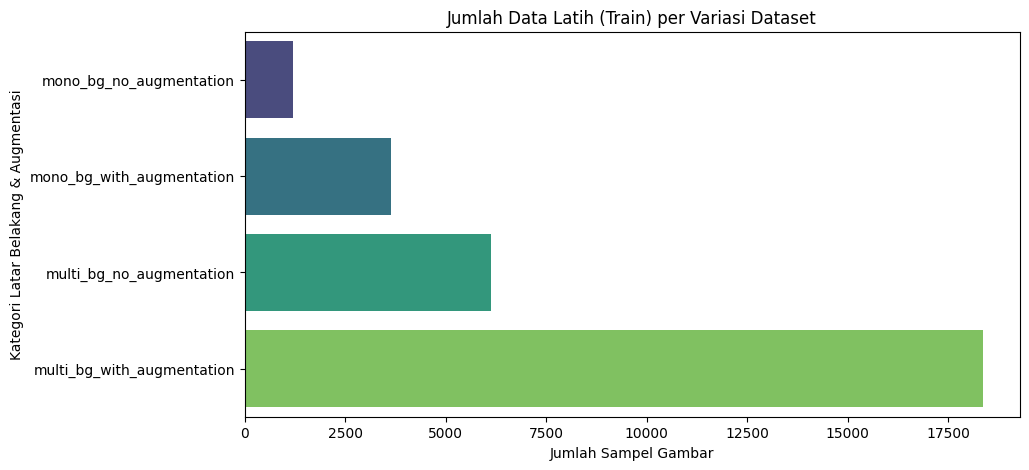

In [6]:
# Menghitung total gambar dan label per dataset (gabungan train+val+test)
total_per_dataset = []

for ds in datasets:
    total_imgs = 0
    total_lbls = 0
    for split in splits:
        img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
        lbl_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', split)
        img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
        lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
        img_files = [f for f in img_files if os.path.isfile(f)]
        lbl_files = [f for f in lbl_files if os.path.isfile(f)]
        total_imgs += len(img_files)
        total_lbls += len(lbl_files)
    total_per_dataset.append({
        'Dataset': ds.replace('sibi_alphabet_', ''),
        'Total Gambar': total_imgs,
        'Total Label': total_lbls,
        'Status': 'Aman' if total_imgs == total_lbls else 'Selisih!'
    })

df_total = pd.DataFrame(total_per_dataset)

rekap_data = []

for ds in datasets:
    for split in splits:
        img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
        lbl_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', split)
        
        # PERBAIKAN: Gunakan '**' dan recursive=True agar bisa masuk ke sub-folder (seperti folder A, B, dst)
        img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
        lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.txt'), recursive=True)
        
        # Filter tambahan untuk memastikan yang terhitung hanya file, bukan nama foldernos
        img_files = [f for f in img_files if os.path.isfile(f)]
        lbl_files = [f for f in lbl_files if os.path.isfile(f)]
        
        rekap_data.append({
            'Tipe Dataset': ds.replace('sibi_alphabet_', ''),
            'Split': split.upper(),
            'Jml Gambar': len(img_files),
            'Jml Label': len(lbl_files),
            'Status': 'Aman' if len(img_files) == len(lbl_files) else 'Selisih!'
        })
        
display(df_total)
df_rekap = pd.DataFrame(rekap_data)

# Tampilkan tabel yang diformat
display(df_rekap)

# Visualisasi total data per dataset
plt.figure(figsize=(10, 5))
sns.barplot(data=df_total, x='Total Gambar', y='Dataset', palette='Set2')
plt.title('Jumlah Total Data (Train+Val+Test) per Variasi Dataset')
plt.xlabel('Jumlah Sampel')
plt.ylabel('Dataset')
plt.show()

# Visualisasi ringkasan jumlah gambar per dataset (hanya data Train)
df_train = df_rekap[df_rekap['Split'] == 'TRAIN']
plt.figure(figsize=(10, 5))
sns.barplot(data=df_train, x='Jml Gambar', y='Tipe Dataset', palette='viridis')
plt.title('Jumlah Data Latih (Train) per Variasi Dataset')
plt.xlabel('Jumlah Sampel Gambar')
plt.ylabel('Kategori Latar Belakang & Augmentasi')
plt.show()

## **3. Pengecekan Keseimbangan Kelas (Class Balance)**

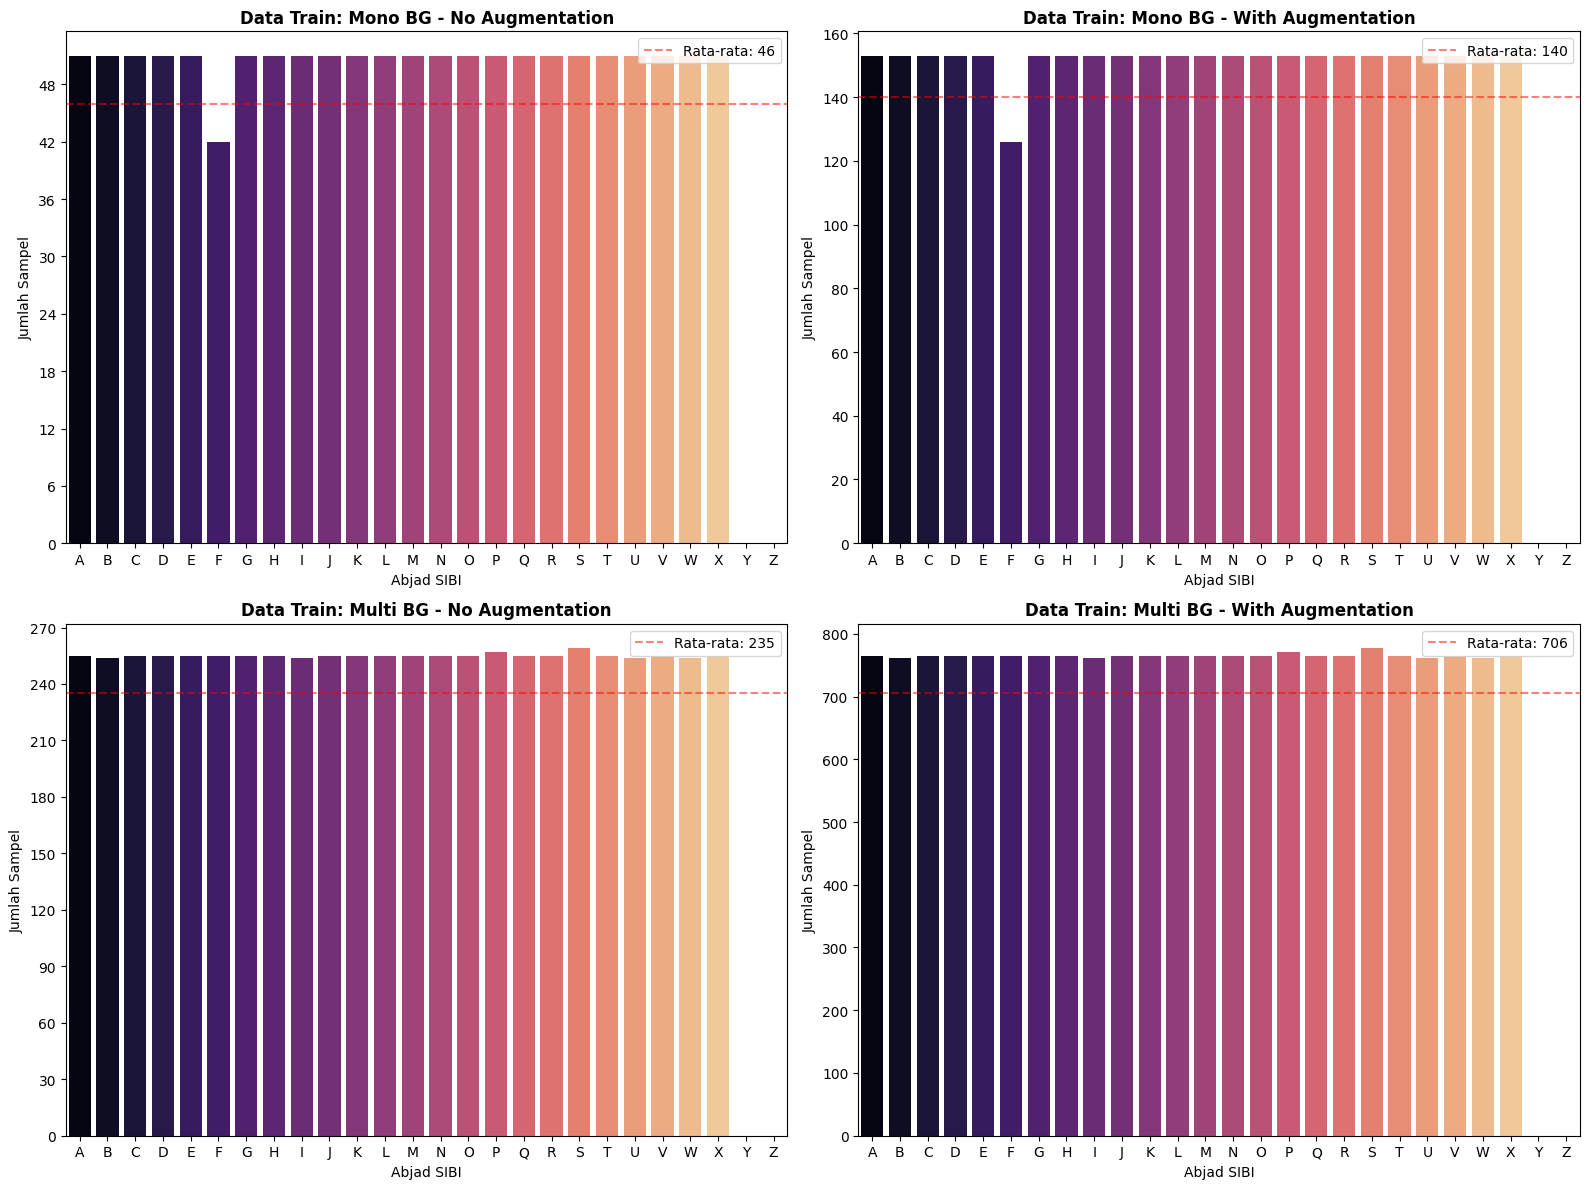

In [4]:
# %% [markdown]
# ## **3. Pengecekan Keseimbangan Kelas (Class Balance) 4 Dataset**

# %%
import string
import matplotlib.ticker as ticker

# Membuat pemetaan kelas dari 0-25 ke A-Z
alphabet = list(string.ascii_uppercase)
class_mapping = {i: letter for i, letter in enumerate(alphabet)}

# Siapkan kanvas 2x2 untuk 4 plot
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

titles = [
    'Mono BG - No Augmentation', 
    'Mono BG - With Augmentation',
    'Multi BG - No Augmentation', 
    'Multi BG - With Augmentation'
]

# Loop untuk menghitung dan mengeplot masing-masing dataset
for idx, ds in enumerate(datasets):
    target_label_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', 'train')
    
    # Pencarian rekursif untuk masuk ke sub-folder kelas
    label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
    label_files = [f for f in label_files if os.path.isfile(f)]
    
    class_counts = {letter: 0 for letter in alphabet}
    
    # Hitung frekuensi per kelas
    for txt_file in label_files:
        with open(txt_file, 'r') as f:
            for line in f.readlines():
                if line.strip():
                    try:
                        # Ambil ID kelas (angka paling pertama)
                        class_id = int(line.split()[0])
                        if class_id in class_mapping:
                            class_counts[class_mapping[class_id]] += 1
                    except ValueError:
                        continue # Abaikan baris yang bukan angka
                        
    # Konversi ke DataFrame
    df_classes = pd.DataFrame(list(class_counts.items()), columns=['Abjad', 'Frekuensi'])
    
    # Plotting ke subplot yang sesuai
    sns.barplot(ax=axes[idx], data=df_classes, x='Abjad', y='Frekuensi', palette='magma')
    
    # Percantik tampilan masing-masing subplot
    axes[idx].set_title(f'Data Train: {titles[idx]}', fontweight='bold', fontsize=12)
    axes[idx].set_xlabel('Abjad SIBI')
    axes[idx].set_ylabel('Jumlah Sampel')
    
    # Tambahkan garis horizontal penanda rata-rata (jika ada isinya)
    if not df_classes['Frekuensi'].sum() == 0:
        mean_freq = int(df_classes['Frekuensi'].mean())
        axes[idx].axhline(y=mean_freq, color='r', linestyle='--', alpha=0.5, 
                          label=f'Rata-rata: {mean_freq}')
        axes[idx].legend(loc='upper right')
        
    # Format sumbu Y agar tidak desimal
    axes[idx].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Sesuaikan jarak antar plot
plt.tight_layout()
plt.show()

# Beri catatan jika ada dataset yang kosong
for ds in datasets:
    target_label_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', 'train')
    label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
    if not label_files:
        print(f"Catatan: Tidak ditemukan file label di '{ds}'. Pastikan folder tidak kosong.")

## **4. Analisis Dimensi Gambar**

Kode ini mengambil sampel acak untuk mengecek konsistensi resolusi (tinggi x lebar) gambar di dalam dataset.

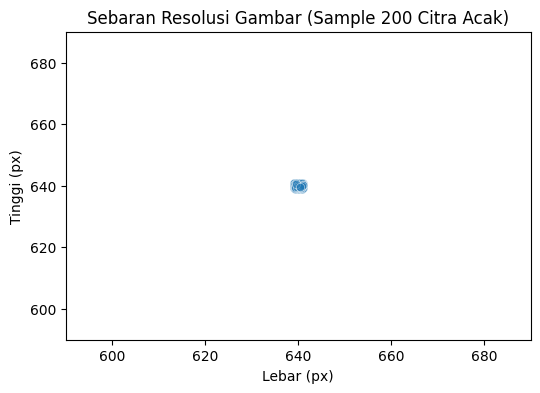

Resolusi rata-rata: 640x640 piksel.


In [5]:
# %% [markdown]
# ## **4. Analisis Dimensi Gambar**

# %%
import random

# Ambil sampel acak dari dataset multi_bg untuk mengecek dimensi
sample_img_dir = os.path.join(BASE_DATA_DIR, datasets[2], 'images', 'train')

# Pencarian rekursif untuk masuk ke sub-folder
all_sample_files = glob.glob(os.path.join(sample_img_dir, '**', '*.*'), recursive=True)
all_sample_files = [f for f in all_sample_files if os.path.isfile(f)]

widths = []
heights = []

# PERBAIKAN: Ambil sampel secara acak menggunakan random.sample
if len(all_sample_files) > 200:
    sample_files = random.sample(all_sample_files, 200)
else:
    sample_files = all_sample_files

# Batasi pengecekan agar memori tidak penuh
for img_path in sample_files:
    img = cv2.imread(img_path)
    if img is not None:
        h, w, _ = img.shape
        widths.append(w)
        heights.append(h)

# Tambahkan sedikit jitter (noise acak) agar titik yang identik tidak menumpuk sempurna
# Ini hanya untuk tujuan visualisasi
widths_jittered = [w + random.uniform(-1, 1) for w in widths]
heights_jittered = [h + random.uniform(-1, 1) for h in heights]

plt.figure(figsize=(6, 4))
sns.scatterplot(x=widths_jittered, y=heights_jittered, alpha=0.6)
plt.title('Sebaran Resolusi Gambar (Sample 200 Citra Acak)')
plt.xlabel('Lebar (px)')
plt.ylabel('Tinggi (px)')

# Atur skala axis agar titiknya terlihat jelas meski resolusinya sama semua
if widths and heights:
    plt.xlim(min(widths) - 50, max(widths) + 50)
    plt.ylim(min(heights) - 50, max(heights) + 50)

plt.show()

# Tambahan error handling jika list kosong
if widths and heights:
    print(f"Resolusi rata-rata: {int(np.mean(widths))}x{int(np.mean(heights))} piksel.")
else:
    print("Tidak ada gambar yang terbaca.")

In [14]:
# %% [markdown]
# ## **2c. Analisis Format File (Ekstensi Gambar & Label)**

# %%
# Kumpulkan semua ekstensi gambar yang ada
image_extensions = set()
label_extensions = set()

for ds in datasets:
    for split in splits:
        img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
        lbl_dir = os.path.join(BASE_DATA_DIR, ds, 'labels', split)
        # Cari semua file gambar
        img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
        img_files = [f for f in img_files if os.path.isfile(f)]
        for f in img_files:
            ext = os.path.splitext(f)[1].lower()
            if ext:
                image_extensions.add(ext)
        # Label selalu .txt, tapi kita catat juga
        lbl_files = glob.glob(os.path.join(lbl_dir, '**', '*.*'), recursive=True)
        lbl_files = [f for f in lbl_files if os.path.isfile(f)]
        for f in lbl_files:
            ext = os.path.splitext(f)[1].lower()
            if ext:
                label_extensions.add(ext)

print("Ekstensi file gambar yang ditemukan:", sorted(image_extensions))
print("Ekstensi file label yang ditemukan:", sorted(label_extensions))

# Jika ada lebih dari satu jenis ekstensi gambar, tampilkan distribusinya per dataset
if len(image_extensions) > 1:
    print("\nDistribusi ekstensi gambar per dataset:")
    for ds in datasets:
        ext_count = {}
        for split in splits:
            img_dir = os.path.join(BASE_DATA_DIR, ds, 'images', split)
            img_files = glob.glob(os.path.join(img_dir, '**', '*.*'), recursive=True)
            img_files = [f for f in img_files if os.path.isfile(f)]
            for f in img_files:
                ext = os.path.splitext(f)[1].lower()
                if ext:
                    ext_count[ext] = ext_count.get(ext, 0) + 1
        print(f"{ds}: {ext_count}")

Ekstensi file gambar yang ditemukan: ['.jpg']
Ekstensi file label yang ditemukan: ['.txt']


In [10]:
# import cv2
# import os
# import glob
# import random
# import matplotlib.pyplot as plt

# # Gunakan sintaks import standar ini
# import mediapipe as mp
# mp_hands = mp.solutions.hands
# mp_drawing = mp.solutions.drawing_utils

# # Inisialisasi model MediaPipe untuk gambar statis
# hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

# # ... (lanjutkan sisa kodemu)
# fig, axes = plt.subplots(1, 2, figsize=(12, 6))
# sample_folders = [
#     os.path.join(BASE_DATA_DIR, datasets[0], 'images', 'train'),
#     os.path.join(BASE_DATA_DIR, datasets[2], 'images', 'train')
# ]

# titles = ['Deteksi pada Mono Background', 'Deteksi pada Multi Background']

# for i, folder in enumerate(sample_folders):
#     all_imgs = glob.glob(os.path.join(folder, '**', '*.*'), recursive=True)
#     all_imgs = [f for f in all_imgs if os.path.isfile(f)]
    
#     if all_imgs:
#         img_path = random.choice(all_imgs)
#         image = cv2.imread(img_path)
#         image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
#         results = hands.process(image_rgb)
        
#         if results.multi_hand_landmarks:
#             for hand_landmarks in results.multi_hand_landmarks:
#                 mp_drawing.draw_landmarks(
#                     image_rgb, hand_landmarks, mp_hands.HAND_CONNECTIONS)
#             axes[i].set_title(f"{titles[i]}\n(Berhasil Terdeteksi)", color='green', fontweight='bold')
#         else:
#             axes[i].set_title(f"{titles[i]}\n(Gagal Terdeteksi!)", color='red', fontweight='bold')
            
#         axes[i].imshow(image_rgb)
#         axes[i].axis('off')
#     else:
#         axes[i].set_title(f"{titles[i]}\n(Folder Kosong)", color='red')
#         axes[i].axis('off')

# plt.tight_layout()
# plt.show()

# hands.close()  # Tambahkan ini untuk release resource

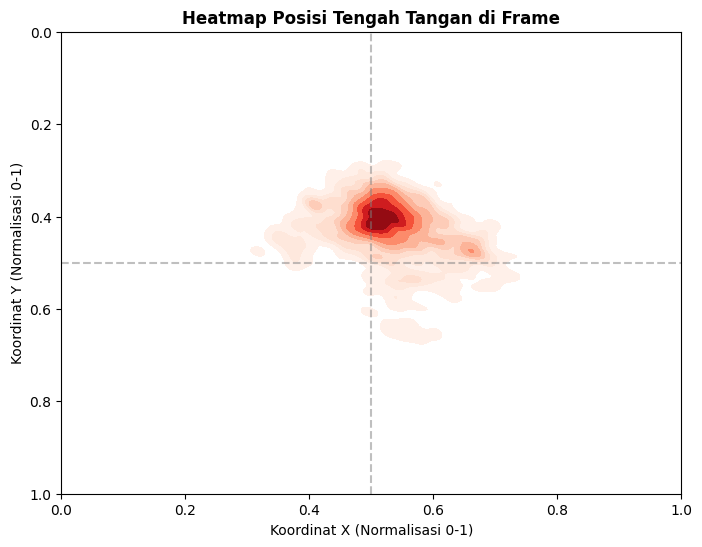

In [11]:
# %% [markdown]
# ## **7. Analisis Spasial (Heatmap Posisi Tangan)**
# Mengetahui di area mana tangan paling sering muncul di dalam frame menggunakan koordinat X dan Y dari label YOLO.

# %%
target_label_dir = os.path.join(BASE_DATA_DIR, datasets[0], 'labels', 'train')
label_files = glob.glob(os.path.join(target_label_dir, '**', '*.txt'), recursive=True)
label_files = [f for f in label_files if os.path.isfile(f)]

x_centers = []
y_centers = []

for txt_file in label_files:
    with open(txt_file, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if len(parts) >= 5:
                # Format YOLO: class x_center y_center width height
                x_centers.append(float(parts[1]))
                y_centers.append(float(parts[2]))

plt.figure(figsize=(8, 6))
# Membuat 2D KDE Plot (Heatmap)
sns.kdeplot(x=x_centers, y=y_centers, cmap="Reds", fill=True, bw_adjust=0.5)

plt.title('Heatmap Posisi Tengah Tangan di Frame', fontweight='bold')
plt.xlabel('Koordinat X (Normalisasi 0-1)')
plt.ylabel('Koordinat Y (Normalisasi 0-1)')

# Set limit dari 0 sampai 1 karena koordinat YOLO dinormalisasi
plt.xlim(0, 1)
plt.ylim(1, 0) # Dibalik karena koordinat (0,0) gambar ada di pojok kiri atas

plt.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.show()

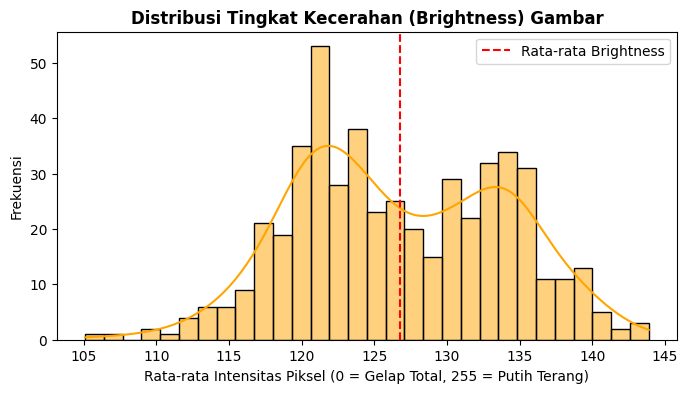

In [12]:
# %% [markdown]
# ## **8. Analisis Intensitas Pencahayaan (Brightness Level)**
# Mengukur sebaran tingkat kecerahan gambar untuk memastikan apakah dataset memiliki variasi pencahayaan (gelap/terang) yang cukup menantang.

# %%
def calculate_brightness(image_path):
    img = cv2.imread(image_path)
    if img is None: return None
    # Konversi ke Grayscale untuk menghitung rata-rata intensitas piksel
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

brightness_levels = []
sample_img_dir = os.path.join(BASE_DATA_DIR, datasets[0], 'images', 'train')
all_imgs = glob.glob(os.path.join(sample_img_dir, '**', '*.*'), recursive=True)
all_imgs = [f for f in all_imgs if os.path.isfile(f)]

# Ambil 500 sampel agar komputasi ringan
sample_files = random.sample(all_imgs, min(500, len(all_imgs)))

for img_path in sample_files:
    bright_val = calculate_brightness(img_path)
    if bright_val is not None:
        brightness_levels.append(bright_val)

plt.figure(figsize=(8, 4))
sns.histplot(brightness_levels, bins=30, kde=True, color='orange')
plt.title('Distribusi Tingkat Kecerahan (Brightness) Gambar', fontweight='bold')
plt.xlabel('Rata-rata Intensitas Piksel (0 = Gelap Total, 255 = Putih Terang)')
plt.ylabel('Frekuensi')
plt.axvline(np.mean(brightness_levels), color='red', linestyle='--', label='Rata-rata Brightness')
plt.legend()
plt.show()